In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath("src"))
from wAMEs.temporal_dynamics import integrate_I_traj_kernel
from wAMEs.plotting import get_plot_style, make_truncated_colormap, apply_axis_style
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np

In [9]:
from wAMEs.core import load_group_statistics

# Load group statistics
network = "Thiers13"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

# Model parameters
nu = 9.5
mu = 1.0
w = 5.0

# Output directory
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

/var/folders/02/c1hvrmj11kx0z457p84l6pbc0000gn/T/ipykernel_94571/3365509791.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


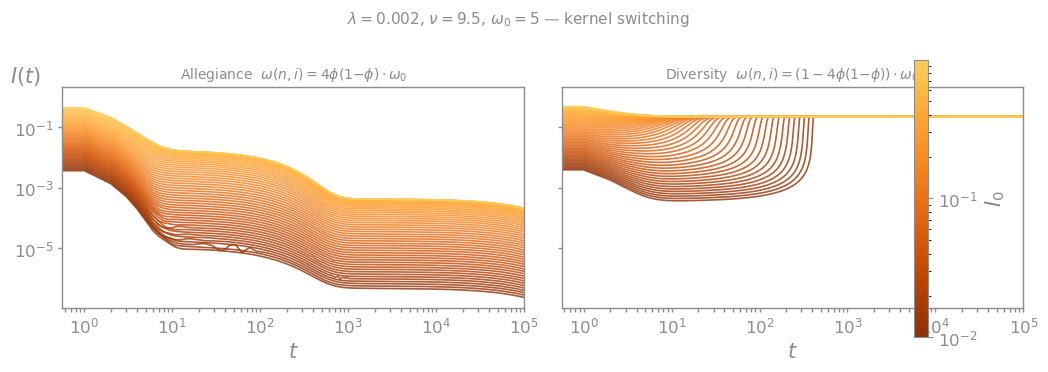

In [10]:
# --- Kernel definitions ---
# phi = i/n is the infected fraction within the group

def w_allegiance(n, i, scale):
    """Nodes flee diverse groups — prefer homogeneous ones (allegiance/homophily).
    Rate peaks at phi=0.5 and is zero at the homogeneous extremes (phi=0 or 1)."""
    phi = i / n
    return scale * 4 * phi * (1 - phi)

def w_diversity(n, i, scale):
    """Nodes flee homogeneous groups — prefer mixed ones (diversity-seeking).
    Rate is large at phi=0 or phi=1 and zero at phi=0.5."""
    phi = i / n
    return scale * (1 - 4 * phi * (1 - phi))

# --- Settings (reuse network/params loaded above) ---
traj_points = 100000
initial_conditions = np.logspace(-2, np.log10(0.99), 51)
lam_kernel = 2e-3
scale = 5.0  # omega_0 — same magnitude as the scalar w=5 baseline

kernels = {
    r"Allegiance  $\omega(n,i)=4\phi(1{-}\phi)\cdot\omega_0$": w_allegiance,
    r"Diversity  $\omega(n,i)=(1-4\phi(1{-}\phi))\cdot\omega_0$": w_diversity,
}

# --- Compute trajectories and plot ---
style = get_plot_style()
cmap = make_truncated_colormap("YlOrBr_r", 0.1, 0.65)
norm = LogNorm(vmin=np.min(initial_conditions), vmax=np.max(initial_conditions))

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.6), sharey=True)

for ax, (label, w_func) in zip(axes, kernels.items()):
    for I0 in initial_conditions:
        t, I_t = integrate_I_traj_kernel(
            lam=lam_kernel,
            w_func=w_func,
            w_args=(scale,),
            state_meta=state_meta,
            nmax=nmax,
            mmax=mmax,
            gm=gm,
            mu=mu,
            nu=nu,
            I0=I0,
            traj_points=traj_points,
        )
        ax.plot(t, I_t, lw=1.2, alpha=0.8, color=cmap(norm(I0)))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(right=1e5)
    ax.set_xlabel(r"$t$", fontsize=style["axis_labelsize"], color=style["gray"])
    ax.set_title(label, fontsize=10, color=style["gray"])
    apply_axis_style(ax, style)

axes[0].set_ylabel(r"$I(t)$", fontsize=style["axis_labelsize"], color=style["gray"], rotation=0)
axes[0].yaxis.set_label_coords(-0.08, 1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label(r"$I_0$", fontsize=style["axis_labelsize"], color=style["gray"])
cbar.ax.tick_params(labelsize=style["tick_labelsize"], colors=style["gray"])
for spine in cbar.ax.spines.values():
    spine.set_edgecolor(style["gray"])

fig.suptitle(
    rf"$\lambda={lam_kernel:.3g}$, $\nu={nu:g}$, $\omega_0={scale:g}$ — kernel switching",
    fontsize=11, color=style["gray"], y=1.02,
)

plt.tight_layout()
plt.show()


Max trajectory deviation: 0.00e+00
Pass (atol=1e-10): True


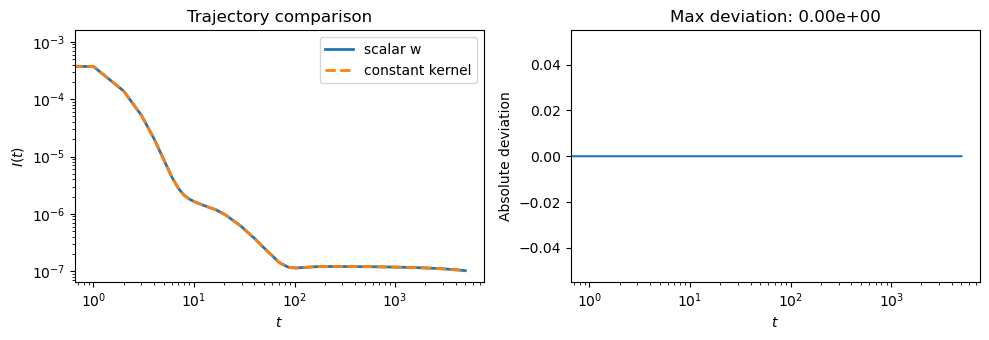

In [11]:
# --- Scalar limit verification ---
# A constant kernel w(n,i) = scale must reproduce integrate_I_traj exactly.
# Max deviation at machine precision (~1e-14) confirms S_w is correct.
# Larger deviation means the pnmat weighting in S_w is wrong.

from wAMEs.temporal_dynamics import integrate_I_traj

test_I0 = 1e-3
test_lam = lam_kernel  # 2e-3
test_traj_points = 5000  # coarse — just need trajectory shape, not resolution

# Scalar baseline
t_scalar, I_scalar = integrate_I_traj(
    lam=test_lam,
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    w=scale,       # w=5.0, same as scale
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

# Constant kernel — should be identical if S_w reduces correctly to I
t_kernel, I_kernel = integrate_I_traj_kernel(
    lam=test_lam,
    w_func=lambda n, i, s: s,   # constant: w(n,i) = scale
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=test_I0,
    traj_points=test_traj_points,
)

max_dev = np.max(np.abs(I_scalar - I_kernel))
print(f"Max trajectory deviation: {max_dev:.2e}")
print(f"Pass (atol=1e-10): {np.allclose(I_scalar, I_kernel, atol=1e-10)}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(t_scalar, I_scalar, label="scalar w", lw=2)
axes[0].plot(t_kernel, I_kernel, "--", label="constant kernel", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$I(t)$")
axes[0].set_title("Trajectory comparison")
axes[0].legend()

axes[1].plot(t_scalar, np.abs(I_scalar - I_kernel))
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("Absolute deviation")
axes[1].set_title(f"Max deviation: {max_dev:.2e}")

plt.tight_layout()
plt.show()